In [1]:
from explore_import import  *
import data_preprocess as dt
import ionbot_preprocess as io

from matplotlib.patches import Patch
from scipy.stats import chi2_contingency
from scipy.stats import wilcoxon
import itertools
import statsmodels.api as sm
from statsmodels.formula.api import ols
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
# where to get pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"
PIPELINE_CL = 'TPP' ; PIPELINE_CL_LW = PIPELINE_CL.lower()
PIPELINE_N_NAME = 'ionbot' ; PIPELINE_N_MODE = 'closed' ; PIPELINE_N = f'{PIPELINE_N_NAME}_{PIPELINE_N_MODE}'; PIPELINE_N_LW = PIPELINE_N.lower()
COMPARE = f'{PIPELINE_CL_LW}_{PIPELINE_N_LW}'
# save plots
#plot_dir = f'{root}/oui-discovery-vv-plot/{COMPARE}'
plot_dir = f'{root}/oui-discovery-vv-test/plot/{COMPARE}'

In [3]:
project_palette={"canon":"orangered","trembl":"yellowgreen","openprot":"cornflowerblue"}
proteins_palette={"Canonical":"orangered","Non-canonical":"cornflowerblue","Reference isoforms":"yellowgreen","Novel isoforms":"gold"}
project_palette2={"canon":"orangered","trembl":"yellowgreen","openprot":"cornflowerblue",
                "Canon_unique":"salmon", "NonCanon_unique":"skyblue", "Shared":"darkkhaki",
                "Canon":"firebrick","Noncanon":"steelblue",f"{PIPELINE_CL}_canon":"lightcoral",f"{PIPELINE_CL}_trembl":"greenyellow",f"{PIPELINE_CL}_openprot":"paleturquoise",
                  "ionbot_canon":"orangered","ionbot_trembl":"yellowgreen","ionbot_openprot":"cornflowerblue",
                 f"{PIPELINE_CL}_canon_unique":"chocolate",
                  f"{PIPELINE_CL}_canon_unique_shared_in_class":"saddlebrown",
                  f"{PIPELINE_CL}_noncanon_unique":"plum",
                  f"{PIPELINE_CL}_noncanon_unique_shared_in_class":"orchid",
                  f"{PIPELINE_CL}_shared":"tan",
                  "ionbot_canon_unique":"salmon",
                  "ionbot_canon_unique_shared_in_class":"rosybrown",
                  "ionbot_noncanon_unique":"skyblue",
                  "ionbot_noncanon_unique_shared_in_class":"mediumturquoise",
                  "ionbot_shared":"darkkhaki",
                 "ionbot_canon_unique_OnlyMod":"firebrick",
                 "ionbot_canon_unique_OnlyUnmod":"indianred",
                 "ionbot_canon_unique_Both":"lightcoral",
                 "ionbot_noncanon_unique_OnlyMod":"royalblue",
                 "ionbot_noncanon_unique_OnlyUnmod":"dodgerblue",
                 "ionbot_noncanon_unique_Both":"lightblue",
                 "ionbot_shared_OnlyMod":"olivedrab",
                 "ionbot_shared_OnlyUnmod":"olive",
                 "ionbot_shared_Both":"darkseagreen",}

In [4]:
peptide_class_order = ["Canon_unique","Shared","NonCanon_unique"]
peptide_classes={"NonCanon_unique":["unique_to_Noncanon",'shared_in_Noncanon'],
                "Canon_unique":["unique_to_Canon",'shared_in_Canon'],
                "Shared":['shared_btw_can_noncan']}
peptide_subclasses = {subcl:pepcl for pepcl, pepsubcl in peptide_classes.items() for subcl in pepsubcl}

In [5]:
dataset_palette={'PXD002057':"lightgrey" ,'PXD005833': 'darkgrey', 'PXD014258': 'dimgrey'}

In [6]:
database_map = {'canon':'Swiss-Prot','trembl':'TrEMBL','openprot':'OpenProt'}
database_order = ["canon","trembl","openprot"]
database_title_order = ["Swiss-Prot","TrEMBL","OpenProt"]

In [7]:
# significance helper
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

### ID rate by database search

In [8]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_idrate_datasets_df.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_idrate_datasets_df.pkl")
# concat
data = pd.concat([data_cl, data_n])
# percent
data['value'] *= 100

/tmp/ipykernel_1116435/1938662343.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l = ax.legend().get_frame()


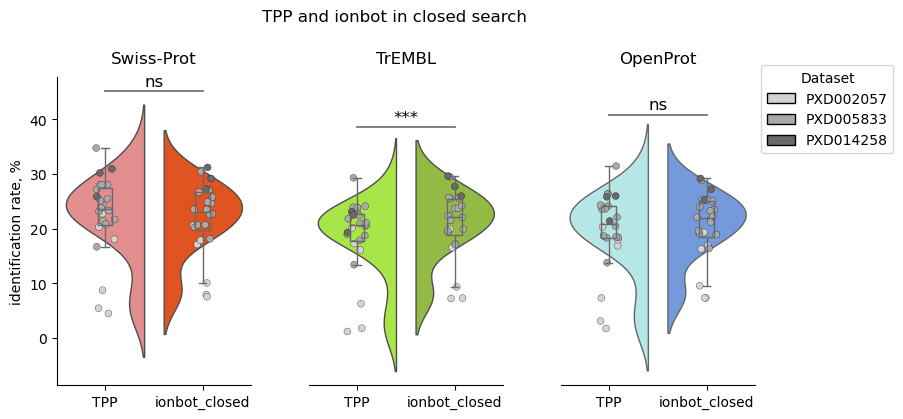

In [11]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)
fig.suptitle(f"{PIPELINE_CL} and {PIPELINE_N_NAME} in {PIPELINE_N_MODE} search", y=1.05)

for i, database in enumerate(database_order):
    subset = data[data['database'] == database]

    # violin
    sns.violinplot(data=subset, 
                   x='pipeline', y='value', 
                   split=True, hue='pipeline', ax=axes[i],
                   inner=None, dodge=False,
                   palette={PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{database}"], 
                            PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{database}"]},
                   linewidth=1)

    # scatter overlay
    for dataset in dataset_palette.keys():
        sns.stripplot(x="pipeline", y="value", hue="dataset",
                      data=subset[subset.dataset == dataset], 
                      jitter=True, ax=axes[i],
                      palette=dataset_palette, edgecolor="black", linewidth=0.2,
                      legend=False, zorder=10)

    # box overlay
    sns.boxplot(data=subset,
                x='pipeline', y='value',
                width=0.15, dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},
                whiskerprops={"color": "dimgrey", "linewidth": 1},
                capprops={"color": "dimgrey", "linewidth": 1},
                medianprops={"color": "dimgrey", "linewidth": 1},
                showfliers=False, ax=axes[i], zorder=50)

    # --- Wilcoxon test between pipelines ---
    vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['value']
    vals_n = subset[subset['pipeline'] == PIPELINE_N]['value']

    # Only test if both groups have paired samples and >0 values
    try:
        if len(vals_cl) == len(vals_n) and len(vals_cl) > 0:
            stat, p = wilcoxon(vals_cl, vals_n)
            stars = significance_stars(p)

            # Add annotation
            y_max = max(subset['value']) * 1.3
            axes[i].plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
            axes[i].text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)
    except ValueError:
        # Skip if not paired
        pass

    axes[i].set_title(database_map[database], pad=10)

# aesthetics
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('') 
    ax.set_xlabel('')
    ax.tick_params(left=False) 
    l = ax.legend().get_frame()
    l.set_edgecolor("white")

# Keep only y-axis on first plot
axes[0].spines['left'].set_visible(True)
axes[0].set_ylabel("identification rate, %") 
axes[0].tick_params(left=True)

# dataset legend
legend_handles = [Patch(facecolor=color, edgecolor='black', label=dataset)
                  for dataset, color in dataset_palette.items()]
fig.legend(handles=legend_handles, title="Dataset", loc='center left', bbox_to_anchor=(0.9, 0.8), frameon=True)

fig.subplots_adjust(wspace=.3)

plt.savefig(f"{plot_dir}/idrate_by_db.svg", format='svg', bbox_inches = 'tight')

In [12]:
# Average ID-rate across databases 
data.groupby('pipeline').apply(lambda x: x['value'].mean())

pipeline
TPP              20.292472
ionbot_closed    21.174810
dtype: float64

In [13]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [14]:
# Run two-way ANOVA
model = ols('value ~ C(pipeline) + C(database) + C(pipeline):C(database)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                              sum_sq     df         F    PR(>F)
C(pipeline)                28.026680    1.0  0.616598  0.433660
C(database)               158.283905    2.0  1.741153  0.179147
C(pipeline):C(database)    45.229572    2.0  0.497534  0.609115
Residual                 6272.618085  138.0       NaN       NaN


In [15]:
a = data[data['database']=='canon']
a1 = a[a['pipeline']=='TPP']
a2 = a[a['pipeline']=='ionbot_closed']
b=a1.merge(a2,on=['sample'])
(b['value_x']-b['value_y']).mean()

0.5661410657850221

In [9]:
a = data[data['database']=='trembl']
a1 = a[a['pipeline']=='TPP']
a2 = a[a['pipeline']=='ionbot_closed']
b=a1.merge(a2,on=['sample'])
(b['value_x']-b['value_y']).mean()

-1.7215756603114625

### ID rate by peptide class

#### all

In [17]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_PEPCL_idrate_datasets_df.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_PEPCL_idrate_datasets_df.pkl")
# concat
data = pd.concat([data_cl, data_n])
# percent
data['value'] *= 100
#remove decoy
data = data[data['peptide_class']!='decoy']
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)
# sum entries of same class per sample and pipeline
data = data.groupby(['pipeline', 'dataset', 'sample', 'peptide_class']).apply(lambda x: x['value'].sum()).to_frame().reset_index().rename(columns={0:'value'})

/tmp/ipykernel_1116435/4231210263.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l=ax.legend().get_frame()


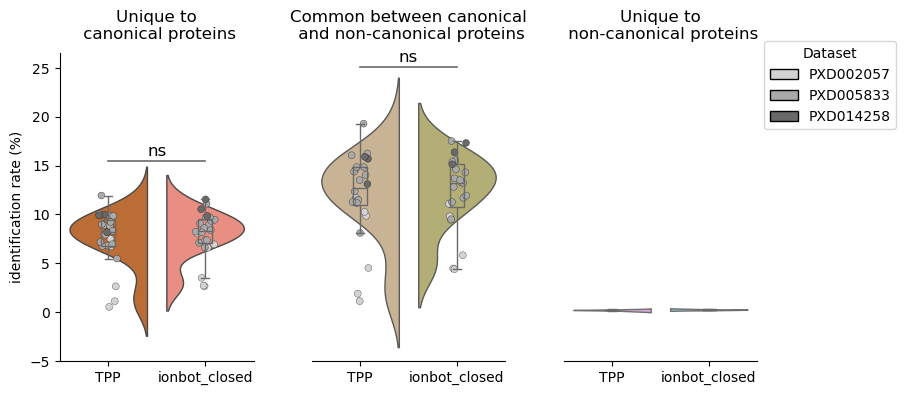

In [18]:
#plot
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)
#Left plot
for i,peptide_class in enumerate(peptide_class_order):
    attribute= "canon_unique" if peptide_class=="Canon_unique" else "noncanon_unique" if peptide_class=="NonCanon_unique" else "shared"
    subset = data[data['peptide_class'] == peptide_class]
    v=sns.violinplot(data=subset, 
                   x='pipeline', y='value', 
                   split=True, hue='pipeline', ax=axes[i],
                   inner=None,dodge=False,
                   palette={PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{attribute}"], PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{attribute}"]},
                   linewidth=1,
                  )
    if peptide_class!="NonCanon_unique":
        for dataset in dataset_palette.keys():
            sns.stripplot(x="pipeline", y="value", hue="dataset", data=subset[(subset.dataset==dataset)], jitter=True, ax=axes[i],
                     palette=dataset_palette,edgecolor="black", linewidth=0.2 ,legend=False, zorder=10)
        # --- Wilcoxon test between pipelines ---
        vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['value']
        vals_n = subset[subset['pipeline'] == PIPELINE_N]['value']
    
        # Only test if both groups have paired samples and >0 values
        try:
            if len(vals_cl) == len(vals_n) and len(vals_cl) > 0:
                stat, p = wilcoxon(vals_cl, vals_n)
                stars = significance_stars(p)
    
                # Add annotation
                y_max = max(subset['value']) * 1.3
                axes[i].plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
                axes[i].text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)
        except ValueError:
            # Skip if not paired
            pass
        
    sns.boxplot(data=subset,
                x='pipeline', y='value', 
                width=0.15,  # Keeps boxplot thin
                dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},  # Thinner box edges
                whiskerprops={"color": "dimgrey", "linewidth": 1},  # Thinner whiskers
                capprops={"color": "dimgrey", "linewidth": 1},  # Thinner caps
                medianprops={"color": "dimgrey", "linewidth": 1},  # Thinner dashed median line
                showfliers=False,  # Hide outliers
                ax=axes[i],
                zorder=50
    )

    attribute_txt= "Unique to\n canonical proteins" if peptide_class=="Canon_unique" else "Unique to\n non-canonical proteins" if peptide_class=="NonCanon_unique" else "Common between canonical\n and non-canonical proteins"
    axes[i].set_title(attribute_txt,pad=10)

#Customize
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('') 
    ax.set_xlabel('')
    ax.tick_params(left=False) 
    l=ax.legend().get_frame()
    l.set_edgecolor("white")

#Keep only the y-axis on the first plot
axes[0].spines['left'].set_visible(True)
axes[0].set_ylabel("identification rate (%)") 
axes[0].tick_params(left=True)

legend_handles = [Patch(facecolor=color, edgecolor='black', label=dataset)
                  for dataset, color in dataset_palette.items()]
fig.legend(handles=legend_handles, title="Dataset", loc='center left', bbox_to_anchor=(0.9, 0.8), frameon=True)

fig.subplots_adjust(wspace=.3)
#plt.tight_layout()

plt.savefig(f"{plot_dir}/idrate_by_pepcl.svg", format='svg', bbox_inches = 'tight')

#### Non-canonical

/tmp/ipykernel_1116435/377172515.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l=axes.legend().get_frame()


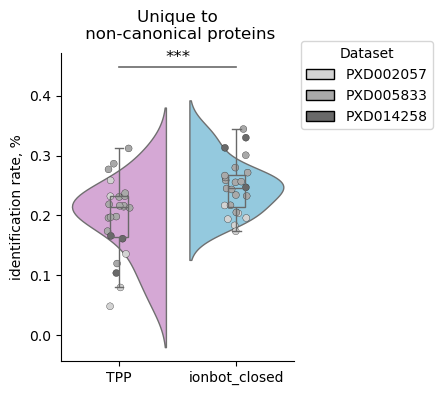

In [19]:
peptide_class_plot = 'NonCanon_unique'
data_plot= data[data['peptide_class'] == peptide_class_plot]

#plot
fig, axes = plt.subplots(1, 1, figsize=(3, 4), sharey=True)
#Left plot
for i,peptide_class in enumerate([peptide_class_plot]):
    attribute= "canon_unique" if peptide_class=="Canon_unique" else "noncanon_unique" if peptide_class=="NonCanon_unique" else "shared"
    subset = data_plot[data_plot['peptide_class'] == peptide_class]
    v=sns.violinplot(data=subset, 
                   x='pipeline', y='value', 
                   split=True, hue='pipeline', ax=axes,
                   inner=None,dodge=False,
                   palette={PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{attribute}"], PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{attribute}"]},
                   linewidth=1,
                  )
    for dataset in dataset_palette.keys():
        sns.stripplot(x="pipeline", y="value", hue="dataset", data=subset[(subset.dataset==dataset)], jitter=True, ax=axes,
                 palette=dataset_palette,edgecolor="black", linewidth=0.2 ,legend=False, zorder=10)
        
    sns.boxplot(data=data_plot[data_plot['peptide_class'] == peptide_class],
                x='pipeline', y='value', 
                width=0.15,  # Keeps boxplot thin
                dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},  # Thinner box edges
                whiskerprops={"color": "dimgrey", "linewidth": 1},  # Thinner whiskers
                capprops={"color": "dimgrey", "linewidth": 1},  # Thinner caps
                medianprops={"color": "dimgrey", "linewidth": 1},  # Thinner dashed median line
                showfliers=False,  # Hide outliers
                ax=axes,
                zorder=50
    )

    attribute_txt= "Unique to\n canonical proteins" if peptide_class=="Canon_unique" else "Unique to\n non-canonical proteins" if peptide_class=="NonCanon_unique" else "Common between canonical\n and non-canonical proteins"
    axes.set_title(attribute_txt, pad = 10)
    # --- Wilcoxon test between pipelines ---
    vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['value']
    vals_n = subset[subset['pipeline'] == PIPELINE_N]['value']

    # Only test if both groups have paired samples and >0 values
    try:
        if len(vals_cl) == len(vals_n) and len(vals_cl) > 0:
            stat, p = wilcoxon(vals_cl, vals_n)
            stars = significance_stars(p)

            # Add annotation
            y_max = max(subset['value']) * 1.3
            axes.plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
            axes.text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)
    except ValueError:
        # Skip if not paired
        pass
#Customize
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False) 
axes.set_ylabel('') 
axes.set_xlabel('')
axes.tick_params(left=False) 
l=axes.legend().get_frame()
l.set_edgecolor("white")

#Keep only the y-axis on the first plot
axes.set_ylabel("identification rate, %") 
axes.tick_params(left=True)

legend_handles = [Patch(facecolor=color, edgecolor='black', label=dataset)
                  for dataset, color in dataset_palette.items()]
fig.legend(handles=legend_handles, title="Dataset", loc='center left', bbox_to_anchor=(0.9, 0.8), frameon=True)

fig.subplots_adjust(wspace=.3)
#plt.tight_layout()

plt.savefig(f"{plot_dir}/idrate_by_pepcl_noncanon.svg", format='svg', bbox_inches = 'tight')

In [20]:
# Average ID-rate across databases 
data_plot.groupby('pipeline').apply(lambda x: x['value'].mean())

pipeline
TPP              0.196836
ionbot_closed    0.247074
dtype: float64

### Peptide reproducability by datasets

In [21]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_peptides_across_samples_PEP_df.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_peptides_across_samples_PEP_df.pkl")
# concat
data = pd.concat([data_cl, data_n])
#remove decoy
data = data[data['peptide_class']!='decoy']
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)
# sum entries of same class per sample and pipeline
data = data.groupby(['pipeline', 'dataset', 'peptide_class','n_samp']).apply(lambda x: x['value'].sum()).to_frame().reset_index().rename(columns={0:'value'})
# percent
data['percent'] = (
    data.groupby(['pipeline', 'dataset',  'peptide_class'])['value']
    .transform(lambda x: 100 * x / x.sum())
)

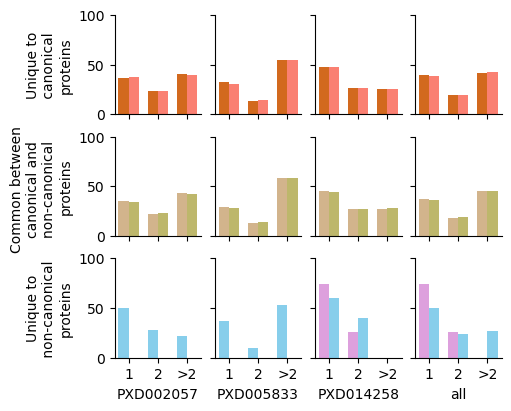

In [22]:
fig, ax = plt.subplots(3,4,layout='constrained',figsize=(5,4),sharex=True,sharey=True)
bar_width = 0.35
colors={PIPELINE_CL:{"Canon_unique":"chocolate",
              "NonCanon_unique":"plum",
              "Shared":"tan"},
       PIPELINE_N:{"Canon_unique":"salmon",
              "NonCanon_unique":"skyblue",
              "Shared":"darkkhaki"}}
for i,peptide_class in enumerate(peptide_class_order):
    row_label=( "Unique to\n canonical \nproteins" if peptide_class=="Canon_unique" 
               else "Unique to\n non-canonical \nproteins" if peptide_class=="NonCanon_unique" 
               else "Common between \ncanonical and \nnon-canonical \nproteins")
    group=data.groupby("peptide_class").get_group(peptide_class)
    for j,(PXD,group_pxd) in enumerate(group.groupby("dataset")):
        pivot_df = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')

        # Pivot both percent and count values
        pivot_percent = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')
        pivot_count = group_pxd.pivot(index='n_samp', columns='pipeline', values='value')
        x = np.arange(len(pivot_df.index))  # positions for "value" groups
        # Plot each pipeline's bars
        for m, pipeline in enumerate(pivot_percent.columns):
            bar_positions = x + m * bar_width
            bar_heights = pivot_percent[pipeline]
            ax[i, j].bar(bar_positions, bar_heights, width=bar_width, label=pipeline, color=colors[pipeline][peptide_class])
            
            # Annotate absolute counts
            #for xpos, yval, count_val in zip(bar_positions, bar_heights, pivot_count[pipeline]):
            #    ax[i, j].text(xpos, yval + 1, str(int(count_val)), ha='center', va='bottom', fontsize=8)
        
        # Set x-ticks and labels
        ax[i,j].set_ylim(0,100)
        ax[i,j].set_xticks(x + bar_width / 2)
        ax[i,j].set_xticklabels(["1","2",">2"])
        if i==2: ax[i, j].set_xlabel(PXD)
        if j==0: ax[i,j].set_ylabel(row_label)  
        spines = ["top","right"]
        for s in spines:
            ax[i,j].spines[s].set_visible(False) 
            
        j+=1

plt.savefig(f"{plot_dir}/pep_repr.svg", format='svg', bbox_inches = 'tight')

In [23]:
data[data['dataset']=='all'].groupby(['pipeline','peptide_class']).apply(lambda x: x[x['n_samp']!='1']['percent'].sum())

pipeline       peptide_class  
TPP            Canon_unique       60.410211
               NonCanon_unique    25.925926
               Shared             63.087871
ionbot_closed  Canon_unique       61.308417
               NonCanon_unique    50.335570
               Shared             63.938710
dtype: float64

### PSM per peptide by peptide class

In [10]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_pepcl_psm_frq.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_pepcl_psm_frq.pkl")
# concat
data = pd.concat([data_cl, data_n])
#remove decoy
data = data[data['peptide_class']!='decoy']
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)
#aggrigate bars hight
data2=pd.DataFrame(columns=["pipeline","peptide_class","bin_size","bin"])
for (pipl,pcl,bin),group in data.groupby(["pipeline","peptide_class","bin"]):
    row=[pipl,pcl,len(group),bin]
    data2.loc[len(data2)]=row

In [11]:
from matplotlib.ticker import FuncFormatter

def k_formatter(x, pos):
    return f"{int(x/1000)}k"

/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)
/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


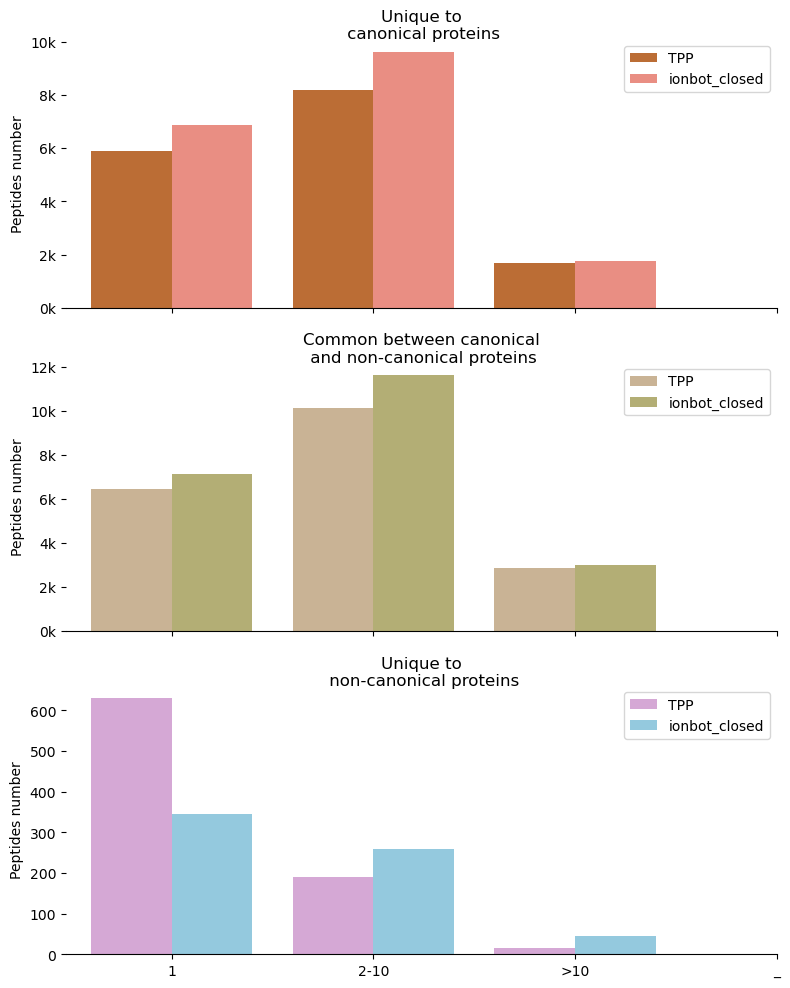

In [13]:
# Define figure and axes: 3 rows, 1 column (adjust cols/rows as you wish)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Iterate through peptide classes and their corresponding subplot axis
for i, (cl, ax) in enumerate(zip(peptide_class_order, axes)):
    attribute = (
        "canon_unique" if cl == "Canon_unique"
        else "noncanon_unique" if cl == "NonCanon_unique"
        else "shared"
    )
    legend_title = (
        "Unique to\n canonical proteins" if cl == "Canon_unique"
        else "Unique to\n non-canonical proteins" if cl == "NonCanon_unique"
        else "Common between canonical\n and non-canonical proteins"
    )

    # Plot directly on the provided subplot axis
    sns.barplot(
        data=data2[data2.peptide_class == cl],
        x="bin", y="bin_size", hue="pipeline",
        palette={
            PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{attribute}"],
            PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{attribute}"]
        },
        alpha=1,
        ax=ax
    )

    # Customize axis labels and ticks
    if i == 2:
        ax.set_xticks(range(4))
        ax.set_xticklabels(["1", "2-10", ">10","_"])
        ax.set_xlabel("PSMs per peptide")
    else:
        ax.set_xlabel("")
        ax.set_xticks([])

    ax.set_ylabel("Peptides number")
    ax.set_title(legend_title, y=0.97)
    if i!=2: ax.yaxis.set_major_formatter(FuncFormatter(k_formatter))

    # Remove spines and style
    sns.despine(ax=ax, left=True)
    ax.legend_.set_title("")  # remove legend title

# Adjust layout to fit everything nicely
plt.tight_layout()

plt.savefig(f"{plot_dir}/psm_per_pep_by_pepcl.svg", format='svg', bbox_inches = 'tight')

In [30]:
a = data2[data2['peptide_class']=='NonCanon_unique']
a1 = a[a['pipeline']==PIPELINE_CL]
a2 = a[a['pipeline']==PIPELINE_N]
print(f'{PIPELINE_CL} >1 PSM',(a1[a1['bin']!=0]['bin_size'].sum()/a1['bin_size'].sum())*100)
print(f'{PIPELINE_N} >1 PSM',(a2[a2['bin']!=0]['bin_size'].sum()/a2['bin_size'].sum())*100)

TPP >1 PSM 24.641148325358852
ionbot_closed >1 PSM 46.84129429892142


### Proteins by database search

In [15]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_bysearch_proteins.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_bysearch_proteins.pkl")
# concat
data = pd.concat([data_cl, data_n])
#preprocess
data["group"]=data.group.map({'singletons': 'unambiguous',"indistinguishable proteins":"indistinguishable proteins"})
data["database"]=data.database.map(database_map)
data["database"] = data["database"].astype("category")
data.database = data.database.cat.set_categories(database_title_order)
data.sort_values(["database"],inplace=True)

In [16]:
data

,pipeline,database,group,value
0,TPP,Swiss-Prot,unambiguous,5495
1,TPP,Swiss-Prot,indistinguishable proteins,801
0,ionbot_closed,Swiss-Prot,unambiguous,4341
1,ionbot_closed,Swiss-Prot,indistinguishable proteins,580
4,TPP,TrEMBL,unambiguous,2035
5,TPP,TrEMBL,indistinguishable proteins,20914
4,ionbot_closed,TrEMBL,unambiguous,1708
5,ionbot_closed,TrEMBL,indistinguishable proteins,18732
2,TPP,OpenProt,unambiguous,1638
3,TPP,OpenProt,indistinguishable proteins,46493


In [32]:
a = data.groupby(['pipeline','database'])['value'].apply(sum).reset_index()
a1 = a[a['pipeline']==PIPELINE_CL]
a2 = a[a['pipeline']==PIPELINE_N]
b = a1.merge(a2,on='database')
1 - (b['value_y']/b['value_x']).mean()

0.20702241935114907

In [33]:
fig = px.bar(data, x="database", y="value", color="group", facet_col="pipeline", labels={"database":"","value":"proteins number"},
            text_auto=True)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    bargap=0, width=900, height=400
)
fig.write_image(f"{plot_dir}/prot_by_db.svg",format='svg')

### Proteins reproducability by group

In [14]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_prot_reproduce_PXD_{PIPELINE_CL_LW}_protcl_counts.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_prot_reproduce_PXD_{PIPELINE_N_LW}_protcl_counts.pkl")
# concat
data = pd.concat([data_cl, data_n])
# percent
data['percent'] = (
    data.groupby(['pipeline', 'dataset',  'search_database','level'])['value']
    .transform(lambda x: 100 * x / x.sum())
)

In [35]:
a = data[(data['dataset']=='all')&(data['level']=='singletons')].groupby(['pipeline','search_database']).apply(lambda x: x[x['n_samp']!='1']['percent'].sum()).reset_index()
a.groupby('pipeline')[0].apply(np.mean)

pipeline
TPP              60.775424
ionbot_closed    68.660001
Name: 0, dtype: float64

#### by dataset

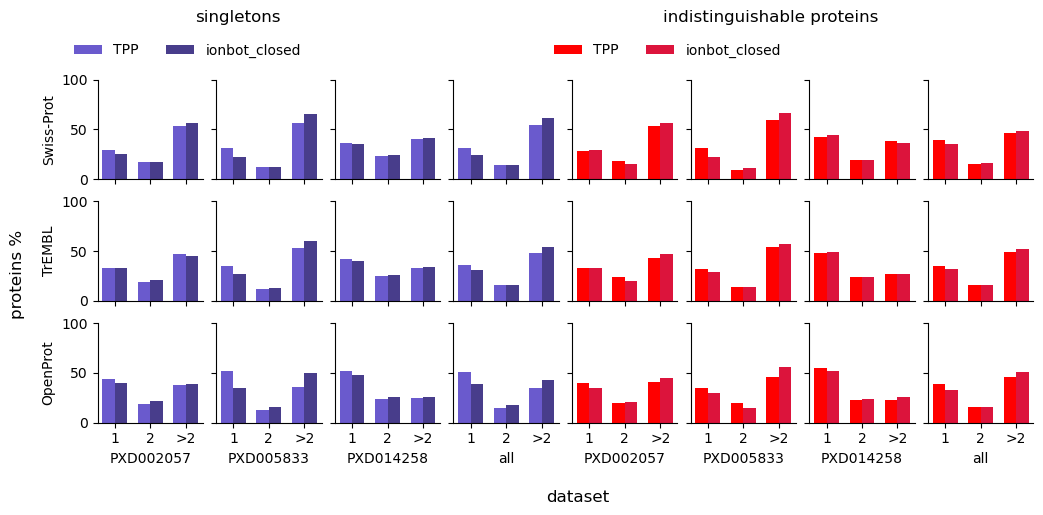

In [36]:
fig, ax = plt.subplots(3,8,layout='constrained',figsize=(10,4),sharex=True,sharey=True)
bar_width = 0.35
group_positions = [1.5, 5.5]
colors={PIPELINE_CL:{"singletons":"slateblue","indistinguishable proteins":"red"},
        PIPELINE_N:{"singletons":"darkslateblue","indistinguishable proteins":"crimson"}}
handles1 = [
    Patch(facecolor=colors[PIPELINE_CL]["singletons"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["singletons"], label=PIPELINE_N)]
handles2 = [
    Patch(facecolor=colors[PIPELINE_CL]["indistinguishable proteins"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["indistinguishable proteins"], label=PIPELINE_N)]

for jj,level_list in enumerate(["singletons","indistinguishable proteins"]):
    for i,database in enumerate(database_order):
        row_label=database_map[database]
        group=data.groupby(["search_database",'level']).get_group((database,level_list))
        j=jj*4
        for PXD,group_pxd in group.groupby("dataset"):
            pivot_df = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')
            x = np.arange(len(pivot_df.index))  # positions for "value" groups

            # Plot each pipeline as a separate bar set
            for m, pipeline in enumerate(pivot_df.columns):
                ax[i,j].bar(x + m * bar_width, pivot_df[pipeline], width=bar_width, label=pipeline,color=colors[pipeline][level_list])
            
            # Set x-ticks and labels
            ax[i,j].set_ylim(0,100)
            ax[i,j].set_xticks(x + bar_width / 2)
            ax[i,j].set_xticklabels(["1","2",">2"])
            if i==2: ax[i, j].set_xlabel(PXD)
            if j==0: ax[i,j].set_ylabel(row_label)  
            spines = ["top","right"]
            for s in spines:
                ax[i,j].spines[s].set_visible(False) 
                

            j+=1
    #titles
    group_label= level_list
    fig.text(
            x=group_positions[jj] / 7.5, 
            y=1.15,             
            s=group_label,
            ha='center',
            va='top',
            fontsize=12,
        )
#xlabel
fig.text(x=0.54,y=-0.05,s="dataset",ha='center',va='top',fontsize=12,)
#ylabel
fig.text(x=-0.02,y=0.6,s="proteins %",ha='center',va='top',fontsize=12,rotation=90)
#legend
fig.legend(
    handles=handles1, 
    loc='lower center', 
    bbox_to_anchor=(0.15, 1),  # Adjust for above the plot
    ncol=2, fontsize=10, frameon=False
)
fig.legend(
    handles=handles2, 
    loc='lower center', 
    bbox_to_anchor=(0.63, 1), 
    ncol=2, fontsize=10, frameon=False
)

#### only all

indistinguishable proteins
singletons


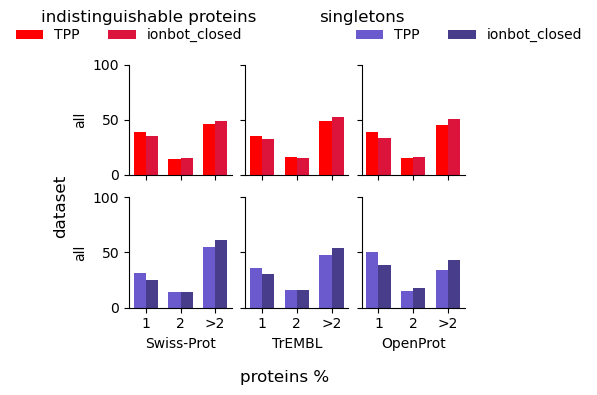

In [37]:
fig, ax = plt.subplots(2,3,layout='constrained',figsize=(4,3),sharex=True,sharey=True)
bar_width = 0.35
group_positions = [1.5, 5.5]
colors={PIPELINE_CL:{"singletons":"slateblue","indistinguishable proteins":"red"},
        PIPELINE_N:{"singletons":"darkslateblue","indistinguishable proteins":"crimson"}}
handles1 = [
    Patch(facecolor=colors[PIPELINE_CL]["indistinguishable proteins"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["indistinguishable proteins"], label=PIPELINE_N)]
handles2 = [
    Patch(facecolor=colors[PIPELINE_CL]["singletons"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["singletons"], label=PIPELINE_N)]

for jj,database in enumerate(database_order):
    for i,level_list in enumerate(["indistinguishable proteins","singletons"]):
        row_label=database_map[database]
        group=data[data['dataset']=='all'].groupby(["search_database",'level']).get_group((database,level_list))
        j=jj
        for PXD,group_pxd in group.groupby("dataset"):
            pivot_df = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')
            x = np.arange(len(pivot_df.index))  # positions for "value" groups

            # Plot each pipeline as a separate bar set
            for m, pipeline in enumerate(pivot_df.columns):
                ax[i,j].bar(x + m * bar_width, pivot_df[pipeline], width=bar_width, label=pipeline,color=colors[pipeline][level_list])
            
            # Set x-ticks and labels
            ax[i,j].set_ylim(0,100)
            ax[i,j].set_xticks(x + bar_width / 2)
            ax[i,j].set_xticklabels(["1","2",">2"])
            if i==1: ax[i, j].set_xlabel(row_label)
            if j==0: ax[i,j].set_ylabel(PXD)  
            spines = ["top","right"]
            for s in spines:
                ax[i,j].spines[s].set_visible(False) 
                

            j+=1
for i,level_list in enumerate(["indistinguishable proteins","singletons"]):
    #titles
    group_label= level_list
    print(group_label)
    fig.text( 
            x=group_positions[i] / 7.5,
            y=1.15,             
            s=group_label,
            ha='center',
            va='top',
            fontsize=12,
        )
#xlabel
fig.text(x=0.54,y=-0.05,s="proteins %",ha='center',va='top',fontsize=12,)
#ylabel
fig.text(x=-0.02,y=0.6,s="dataset",ha='center',va='top',fontsize=12,rotation=90)
#legend
fig.legend(
    handles=handles1, 
    loc='lower center', 
    bbox_to_anchor=(0.15, 1),  # Adjust for above the plot
    ncol=2, fontsize=10, frameon=False
)
fig.legend(
    handles=handles2, 
    loc='lower center', 
    bbox_to_anchor=(1, 1), 
    ncol=2, fontsize=10, frameon=False
)

plt.savefig(f"{plot_dir}/prot_repr_all_dataset.svg", format='svg', bbox_inches = 'tight')

### Number of proteins per protein class

In [38]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_byprotclass_proteins.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_byprotclass_proteins.pkl")
# concat
data = pd.concat([data_cl, data_n])
# only op
data = data[data['search'] == 'openprot']
# preprocess
data["group"]=data.group.map({'singletons': 'unambiguous',"indistinguishable proteins":"indistinguishable proteins"})
data["protein_class"]=data.protein_class.map({'Canonical': 'Canonical proteins', 'NonCanonical': 'Non-canonical proteins'})
data.sort_values("protein_class",inplace=True)

In [39]:
data

,pipeline,search,protein_class,group,value
2,TPP,openprot,Canonical proteins,unambiguous,1616
3,TPP,openprot,Canonical proteins,indistinguishable proteins,46505
2,ionbot_closed,openprot,Canonical proteins,unambiguous,1064
3,ionbot_closed,openprot,Canonical proteins,indistinguishable proteins,32877
4,TPP,openprot,Non-canonical proteins,unambiguous,22
5,TPP,openprot,Non-canonical proteins,indistinguishable proteins,0
4,ionbot_closed,openprot,Non-canonical proteins,unambiguous,109
5,ionbot_closed,openprot,Non-canonical proteins,indistinguishable proteins,0


In [40]:
for protein_class, df in data.groupby('protein_class'):
    save_label = 'canon' if protein_class == 'Canonical proteins' else 'noncanon'
    fig = px.bar(df, x="protein_class", y="value", color="group", facet_col="pipeline", labels={"protein_class":"","value":"proteins number"},
            text_auto=True)
    fig.update_layout(
        plot_bgcolor="white",
        paper_bgcolor="white",
        bargap=0, width=450, height=300
    )
    fig.write_image(f"{plot_dir}/prot_by_protcl_{save_label}.svg",format='svg')

### PSM per protein

In [41]:
from matplotlib.ticker import FuncFormatter
# Custom formatter function for y-axis
def k_formatter(x, pos):
    """Format large numbers as 1k, 2.5k, etc."""
    if x >= 1000:
        return f"{x/1000:.0f}k" if x % 1000 == 0 else f"{x/1000:.1f}k"
    else:
        return f"{int(x)}"

In [43]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_psm_per_prot.pkl"); data_cl['pipeline'] = PIPELINE_CL
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_psm_per_prot.pkl"); data_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([data_cl, data_n])
# bin
bins = [[0],[1],list(range(2,10+1)),list(range(10,10000))]
bins_i = [(i,b) for i, b in enumerate(bins)]
data['bin'] = data['value'].apply(lambda x: [i for i,b in bins_i if x in b][0])
# ensure that only present proteins are included
data = data[data['bin']>0]
# sum proteins
data = data.groupby(['pipeline','level','protein_class','bin']).apply(len).to_frame().reset_index().rename(columns={0:'bin_size'})

In [44]:
color_map = {
    PIPELINE_CL:{
        "Canonical": {
            "Singleton": project_palette2[f"{PIPELINE_CL}_canon_unique"],
            "Group": project_palette2[f"{PIPELINE_CL}_shared"],
        },
        "NonCanonical": {
            "Singleton": project_palette2[f"{PIPELINE_CL}_noncanon_unique"],
            "Group": project_palette2[f"{PIPELINE_CL}_shared"],
        }
    },
    PIPELINE_N:{
        "Canonical": {
            "Singleton": project_palette2[f"{PIPELINE_N_NAME}_canon_unique"],
            "Group": project_palette2[f"{PIPELINE_N_NAME}_shared"],
        },
        "NonCanonical": {
            "Singleton": project_palette2[f"{PIPELINE_N_NAME}_noncanon_unique"],
            "Group": project_palette2[f"{PIPELINE_N_NAME}_shared"],
        }
    },
}

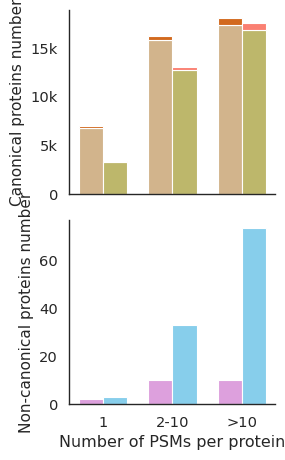

In [45]:
sns.set_theme(style="white", context="paper", font_scale=1.2)

# Ensure consistent order
protein_classes = sorted(data['protein_class'].unique())
bins = [1,2,3]
levels = sorted(data['level'].unique())
pipelines = sorted(data['pipeline'].unique())

fig, axes = plt.subplots(
    nrows=len(protein_classes),
    ncols=1,
    figsize=(3, 2.5 * len(protein_classes)),
    sharex=True,
    sharey=False,
)

if len(protein_classes) == 1:
    axes = [axes]

bar_width = 0.35  # width of each pipeline bar
gap = 0.15        # gap between bin groups

for i, protein_class in enumerate(protein_classes):
    ax = axes[i]

    # X positions for each bin group
    x_base = np.arange(len(bins))
    total_bar_width = bar_width * len(pipelines)
    offsets = np.linspace(-total_bar_width/2 + bar_width/2, total_bar_width/2 - bar_width/2, len(pipelines))

    for j, pipeline in enumerate(pipelines):
        df_subset = data[(data['pipeline']==pipeline) & (data['protein_class']==protein_class)]
        # Pivot: index=bin, columns=level, values=sum(bin_size)
        df_pivot = df_subset.pivot_table(index='bin', columns='level', values='bin_size', aggfunc='sum').reindex(index=bins, columns=levels, fill_value=0)

        bottom = np.zeros(len(df_pivot))
        for level in df_pivot.columns:
            heights = df_pivot[level].values
            ax.bar(
                x_base + offsets[j],
                heights,
                bottom=bottom,
                width=bar_width,
                color=[color_map[pipeline][protein_class][level]]*len(heights),
                label=f"{pipeline} | {level}" if i==0 else None
            )
            bottom += heights

    # Axis formatting
    ax.set_xticks(x_base)
    ax.set_xticklabels(['1', '2-10', '>10'])
    ax.set_xlabel("Number of PSMs per protein" if i == len(protein_classes)-1 else "")
    ax.set_ylabel(f"{protein_class if protein_class=='Canonical' else 'Non-canonical'} proteins number", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(k_formatter))
    sns.despine(ax=ax)

# Shared legend
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center', ncol=len(labels), title="Pipeline | Level")

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(f"{plot_dir}/psm_per_prot_by_pepcl.svg", format='svg', bbox_inches = 'tight')

In [46]:
data[data['protein_class']=='NonCanonical'].groupby('pipeline').apply(lambda x: x[x['bin']!=1]['bin_size'].sum()/x['bin_size'].sum())

pipeline
TPP              0.909091
ionbot_closed    0.972477
dtype: float64

### Peptide per prot

In [47]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_pep_per_prot.pkl"); data_cl['pipeline'] = PIPELINE_CL
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_pep_per_prot.pkl"); data_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([data_cl, data_n])
# bin
bins = [[0],[1],list(range(2,10+1)),list(range(10,10000))]
bins_i = [(i,b) for i, b in enumerate(bins)]
data['bin'] = data['value'].apply(lambda x: [i for i,b in bins_i if x in b][0])
# ensure that only present proteins are included
data = data[data['bin']>0]
# sum proteins
data = data.groupby(['pipeline','level','protein_class','bin']).apply(len).to_frame().reset_index().rename(columns={0:'bin_size'})

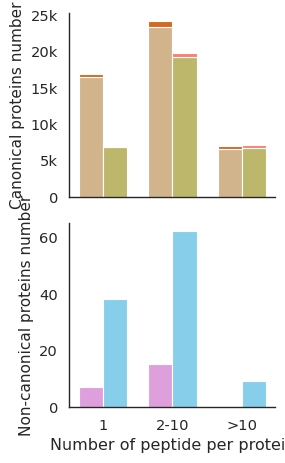

In [48]:
sns.set_theme(style="white", context="paper", font_scale=1.2)

# Ensure consistent order
protein_classes = sorted(data['protein_class'].unique())
bins = [1,2,3]
levels = sorted(data['level'].unique())
pipelines = sorted(data['pipeline'].unique())

fig, axes = plt.subplots(
    nrows=len(protein_classes),
    ncols=1,
    figsize=(3, 2.5 * len(protein_classes)),
    sharex=True,
    sharey=False,
)

if len(protein_classes) == 1:
    axes = [axes]

bar_width = 0.35  # width of each pipeline bar
gap = 0.15        # gap between bin groups

for i, protein_class in enumerate(protein_classes):
    ax = axes[i]

    # X positions for each bin group
    x_base = np.arange(len(bins))
    total_bar_width = bar_width * len(pipelines)
    offsets = np.linspace(-total_bar_width/2 + bar_width/2, total_bar_width/2 - bar_width/2, len(pipelines))

    for j, pipeline in enumerate(pipelines):
        df_subset = data[(data['pipeline']==pipeline) & (data['protein_class']==protein_class)]
        # Pivot: index=bin, columns=level, values=sum(bin_size)
        df_pivot = df_subset.pivot_table(index='bin', columns='level', values='bin_size', aggfunc='sum').reindex(index=bins, columns=levels, fill_value=0)

        bottom = np.zeros(len(df_pivot))
        for level in df_pivot.columns:
            heights = df_pivot[level].values
            ax.bar(
                x_base + offsets[j],
                heights,
                bottom=bottom,
                width=bar_width,
                color=[color_map[pipeline][protein_class][level]]*len(heights),
                label=f"{pipeline} | {level}" if i==0 else None
            )
            bottom += heights

    # Axis formatting
    ax.set_xticks(x_base)
    ax.set_xticklabels(['1', '2-10', '>10'])
    ax.set_xlabel("Number of peptide per protein" if i == len(protein_classes)-1 else "")
    ax.set_ylabel(f"{protein_class if protein_class=='Canonical' else 'Non-canonical'} proteins number", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(k_formatter))
    sns.despine(ax=ax)

# Shared legend
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center', ncol=len(labels), title="Pipeline | Level")

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(f"{plot_dir}/pep_per_prot_by_pepcl.svg", format='svg', bbox_inches = 'tight')

In [49]:
data[data['protein_class']=='NonCanonical'].groupby('pipeline').apply(lambda x: x[x['bin']!=1]['bin_size'].sum()/x['bin_size'].sum())

pipeline
TPP              0.681818
ionbot_closed    0.651376
dtype: float64

### Protein unique sequence coverage

In [50]:
#load
data_cl = pd.read_pickle(f"{results_dir}_test/{PIPELINE_CL_LW}_unique_peptide_aa_coverege_df.pkl"); data_cl['pipeline'] = PIPELINE_CL
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_unique_peptide_aa_coverege_df.pkl"); data_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([data_cl, data_n])
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)

/tmp/ipykernel_1116435/148251283.py:47: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



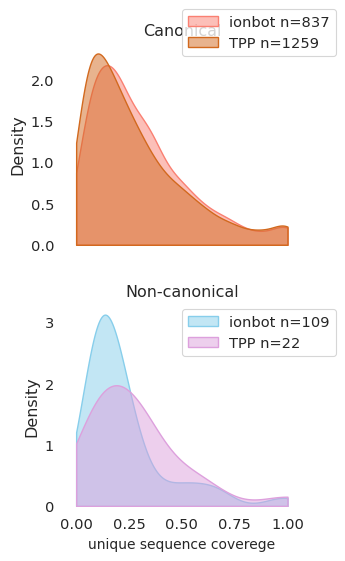

In [51]:
gs = (grid_spec.GridSpec(2,1))
gs.update(hspace= 0.3)
fig = plt.figure(figsize=(3,6))
i = 0
#creating empty list
ax_objs = []
for attribute in ["Canonical","Non-canonical"]:
    # creating new axes object and appending to ax_objs
    ax_objs.append(fig.add_subplot(gs[i:i+1, 0:]))

    color= "noncanon_unique" if attribute=="Non-canonical" else "canon_unique"
    peptide_class="NonCanon_unique" if attribute=="Non-canonical" else "Canon_unique"
    # plotting the distribution
    data1=data.loc[(data.peptide_class==peptide_class)&(data.pipeline==PIPELINE_N),'value']
    
    plot1 = sns.kdeplot(data1, ax=ax_objs[-1],clip=(0,1),
                        color=project_palette2[f"{PIPELINE_N_NAME}_{color}"], 
                        lw=1,label=f"{PIPELINE_N_NAME} n={len(data1)}",fill=True,alpha=0.5)
    
    data2=data.loc[(data.peptide_class==peptide_class)&(data.pipeline==PIPELINE_CL),'value']
    
    plot2 = sns.kdeplot(data2, ax=ax_objs[-1],clip=(0,1),
                        color=project_palette2[f"{PIPELINE_CL}_{color}"], 
                        lw=1,label=f"{PIPELINE_CL} n={len(data2)}",fill=True,alpha=0.5)

    # make background transparent
    rect = ax_objs[-1].patch
    rect.set_alpha(0)

    if i == 1:
        ax_objs[-1].set_xlabel("unique sequence coverege", fontsize=10)
    else:
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_xlabel("")
    
    spines = ["top","right","left","bottom"]
    for s in spines:
        ax_objs[-1].spines[s].set_visible(False)
    
    ax_objs[-1].set_title(attribute)
    if i==0: pos=(1.05,0.95)
    if i==1: pos=(1.05,0.45)
    ax_objs[-1].legend(bbox_to_anchor=pos,bbox_transform=fig.transFigure)

    i += 1

plt.tight_layout()

plt.savefig(f"{plot_dir}/proteotypic_pep_coverage.svg", format='svg', bbox_inches = 'tight')

In [52]:
data.groupby(['pipeline','peptide_class']).apply(lambda x: x['value'].mean())

pipeline       peptide_class  
TPP            Canon_unique       0.283672
               NonCanon_unique    0.283785
ionbot_closed  Canon_unique       0.304818
               NonCanon_unique    0.227424
dtype: float64

In [53]:
#look at length of protein with proteotypic peptides - no difference now
#put this plots in the right top corner of coverege plots

In [54]:
OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

In [55]:
# collect protein length
prot_len=[]
for (pipeline, peptide_class, protein), group in data.reset_index().groupby(['pipeline',"peptide_class",'index']):
    prot_len += [[pipeline, peptide_class, protein, len(str(OPfasta[protein].seq))]]
prot_len = pd.DataFrame(prot_len, columns=['pipeline',"peptide_class",'protein','prot_len'])

In [56]:
# % of singleton proteins <= 100 aa
prot_len.groupby(['pipeline',"peptide_class"]).apply(lambda x: (len(x[x['prot_len']<=100])/len(x))*100 )

pipeline       peptide_class  
TPP            Canon_unique        9.769658
               NonCanon_unique    50.000000
ionbot_closed  Canon_unique        6.810036
               NonCanon_unique    41.284404
dtype: float64

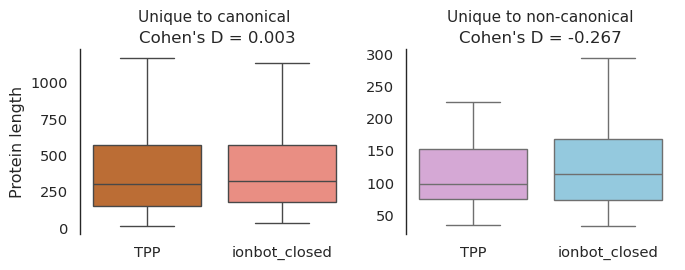

In [57]:
# Define order and figure
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

for i, peptide_class in enumerate(["Canon_unique", "NonCanon_unique"]):
    ax = axes[i]
    color = "noncanon_unique" if peptide_class == "NonCanon_unique" else "canon_unique"
    subset = prot_len[prot_len["peptide_class"] == peptide_class]
    
    # Calculate Cohen’s d
    c0 = subset[subset["pipeline"] == PIPELINE_CL]["prot_len"].tolist()
    c1 = subset[subset["pipeline"] == PIPELINE_N]["prot_len"].tolist()
    cohens_d = (np.mean(c0) - np.mean(c1)) / np.sqrt((np.std(c0) ** 2 + np.std(c1) ** 2) / 2)

    # Boxplot
    sns.boxplot(
        x="pipeline", y="prot_len", hue="pipeline", data=subset, showfliers=False,
        ax=ax,
        palette={
            PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{color}"],
            PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{color}"],
        },
    )
    sns.despine(ax=ax, bottom=True)
    
    # Axis labels
    ax.set_xlabel("")
    if i == 0:
        ax.set_ylabel("Protein length")
    else:
        ax.set_ylabel("")
    
    # Add title & annotation
    title = "Unique to canonical" if peptide_class == "Canon_unique" else "Unique to non-canonical"
    ax.set_title(title, fontsize=11, pad=20)
    ax.text(
        0.8, 1.1, f"Cohen's D = {round(cohens_d, 3)}",
        transform=ax.transAxes, fontsize=12, ha="right", va="top"
    )
    
    # Remove duplicate legends

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(f"{plot_dir}/singleton_prot_len.svg", format='svg', bbox_inches = 'tight')

## S: Peptides' class switch between pipelines

In [58]:
import ast
import tpp_preprocess as tpp

In [59]:
# classic pipeline PSM

processed_dir=f"{root}/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch241125"
processed_paths_cl=dt.list_files(processed_dir)
psm_filt_cl = []
for parent, files in processed_paths_cl.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if (file.startswith("groupwalk_output_")) and (not file.endswith("_pep.csv")) : # omit peptide-level
            data = pd.read_csv(os.path.join(parent, file))
            psm_filt_cl += [data]
psm_filt_cl = pd.concat(psm_filt_cl)
psm_filt_cl = psm_filt_cl[(psm_filt_cl['global_q'] < 0.01)&(psm_filt_cl['isCanonical'] != 'Contam')]
psm_filt_cl['protein'] = psm_filt_cl['protein'].apply(lambda x: ast.literal_eval(x))
psm_filt_cl['isProteotypic'] = psm_filt_cl['protein'].apply(lambda x: len(x)==1)

# new pipeline PSM
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths_n=dt.list_files(processed_dir)
# leave only non-entrapment and closed search, only search files
tmp = processed_paths_n.copy()
for parent, files in processed_paths_n.items():
    if '.v0.11.4' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_n = tmp
psm_filt_n = []
for parent, files in processed_paths_n.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-closed-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-2])
            search_database = parent.split('/')[-1].split('-')[-1] ;dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file ; data['search_database'] = search_database ; data['dataset'] = dataset
            psm_filt_n += [data]
psm_filt_n = pd.concat(psm_filt_n)
psm_filt_n = psm_filt_n[(psm_filt_n['q.value'] < 0.01)&(psm_filt_n['isCanonical'] != 'Contam')]
psm_filt_n['proteins'] = psm_filt_n['proteins'].apply(lambda x: x.split(';'))
psm_filt_n['isProteotypic'] = psm_filt_n['proteins'].apply(lambda x: len(x)==1)
psm_filt_n["peptide_class"]=psm_filt_n["proteins"].apply(tpp.classify_peptide_tpp)

# select openprot
psm_filt_cl = psm_filt_cl[psm_filt_cl['search_database'] == 'openprot']
psm_filt_n = psm_filt_n[psm_filt_n['search_database'] == 'openprot']

tpp_pride_reanalysis_arch241125/
    tpp-identified-protein-groups-all-datasets.csv.gz
    PXD005833/
        PXD005833-canon/
            groupwalk_output_AM15_canon_PeptideProphet_pep.csv
            AM10_canon_PeptideProphet_pep-subgroups_Occam.tsv
            AM20_canon_PeptideProphet_pep-subgroups_Occam.tsv
            AM13_canon_PeptideProphet_pep-protein-inference-input.pout
            AM8_canon_PeptideProphet_pep-protein-inference-input.pout
            AM14_canon_PeptideProphet_pep-groups_Occam.tsv
            AM19_canon_PeptideProphet.csv
            AM18_canon_PeptideProphet.csv
            AM14_canon_PeptideProphet_pep-subgroups_Occam.tsv
            AM18_canon_PeptideProphet_pep-protein-inference-input.pout
            AM11_canon_PeptideProphet_pep.csv
            AM18_canon_PeptideProphet_pep_protein_groups_Occam.csv
            AM13_canon_PeptideProphet_pep-groups_Occam.tsv
            groupwalk_output_AM14_canon_PeptideProphet_pep.csv
            AM18_canon_PeptideProp

In [60]:
#create a common key that identifies spectra
psm_filt_cl['scan_name'] = psm_filt_cl['start_scan'].astype(str) + '_' + psm_filt_cl['spectrum_file'].str.replace('ESC-HF-','')
psm_filt_n['scan_name'] = psm_filt_n['scan'].astype(str) + '_' + psm_filt_n['spectrum_file']

In [61]:
# combine
psm_filt_comb = pd.merge(psm_filt_cl, psm_filt_n, how="outer",on="scan_name", suffixes=(f'_{PIPELINE_CL}', f'_{PIPELINE_N}'))

In [62]:
#hw many are in common - Flase-False

(psm_filt_comb[[f"spectrum_file_{PIPELINE_CL}",f"spectrum_file_{PIPELINE_N}"]].isna().value_counts()/len(psm_filt_comb))*100

spectrum_file_TPP  spectrum_file_ionbot_closed
False              False                          73.907288
True               False                          14.039716
False              True                           12.052996
Name: count, dtype: float64

In [63]:
#switch, others unidentified in either search

ann_data=psm_filt_comb[[f"peptide_class_{PIPELINE_CL}",f"peptide_class_{PIPELINE_N}"]].value_counts()

In [64]:
nodes=["unidentified","Decoy","unique_to_Noncanon",'shared_in_Noncanon',"unique_to_Canon",'shared_in_Canon','shared_btw_can_noncan']
nodes_names=[f"{PIPELINE_CL}:"+x for x in nodes]+[f"{PIPELINE_N}:"+x for x in nodes]
source_target_nodes=list(itertools.combinations(nodes_names, 2))
#filter out source-source, target-target
source_target_nodes=[n for n in source_target_nodes if n[0].split(":")[0]!=n[1].split(":")[0]]
#corresponding indx
source_target_indx=[(nodes.index(n[0].split(":")[1]),nodes.index(n[1].split(":")[1])+len(nodes)) for n in source_target_nodes]

In [65]:
#fill values
sankey_data=pd.DataFrame({"source_name": [n[0].split(":")[1] for n in source_target_nodes],
                          "target_name": [n[1].split(":")[1] for n in source_target_nodes],
                         "link_source":[i[0] for i in source_target_indx],
                         "link_target":[i[1] for i in source_target_indx],
                         "link_value":[ann_data[(n[0].split(":")[1],  n[1].split(":")[1])] if (n[0].split(":")[1],  n[1].split(":")[1]) in ann_data.index.tolist() else np.nan for n in source_target_nodes ]
                          }
                        )

In [66]:
#fill where PIPELINE_CL unidentified
#sankey_data[sankey_data.link_value.isna()]
a=psm_filt_comb[psm_filt_comb[f"spectrum_file_{PIPELINE_CL}"].isna()][f"peptide_class_{PIPELINE_N}"].value_counts()
b=sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.source_name=="unidentified")]
b['link_value'] = b['target_name'].map(a.to_dict())
sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.source_name=="unidentified")]=b
#Fill where ionbot is unidentified
a=psm_filt_comb[psm_filt_comb[f"spectrum_file_{PIPELINE_N}"].isna()][f"peptide_class_{PIPELINE_CL}"].value_counts()
b=sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.target_name=="unidentified")]
b['link_value'] = b['source_name'].map(a.to_dict())
sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.target_name=="unidentified")]=b

/tmp/ipykernel_1116435/2732165016.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1116435/2732165016.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



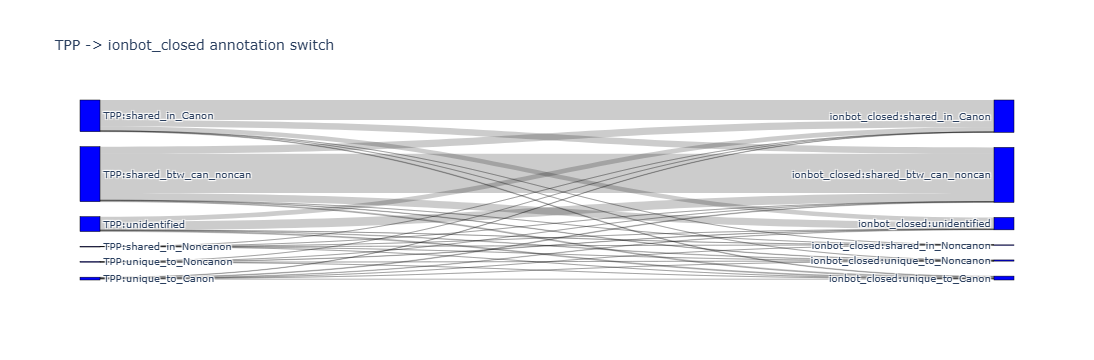

In [67]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = nodes_names,
      color = "blue"
    ),
    link = dict(
      source = sankey_data.link_source.tolist(),
      target = sankey_data.link_target.tolist(),
      value = sankey_data.link_value.tolist()
  ))])

fig.update_layout(title_text=f"{PIPELINE_CL} -> {PIPELINE_N} annotation switch", font_size=10)
#fig.write_image(f".svg")
fig.show()

#### plot like Enrico

In [68]:
#From Enrico, modified
def define_colors(x):
    x=x.split(":")[1]
    if x.startswith('Canonical'):
        return mypalette[0]
    elif x.startswith('NonCanonical'):
        return mypalette[1]
    elif x.startswith('Unidentified'):
        return mypalette[-2]
    elif x.startswith('Decoy'):
        return mypalette[-4]
        
map_enrico_peptide_class={i:"Canonical" if "_Canon" in i or "shared_btw_" in i else "NonCanonical" for k,v in peptide_classes.items() for i in v}
map_enrico_peptide_class.update({"Decoy":"Decoy","decoy":"Decoy"})
#map_enrico_ptm={"unmodified":"Unmodified/Expected","variable":"Unmodified/Expected","unexpected":"Unexpected"}


In [69]:
data=psm_filt_comb.copy(deep=True)
# correct peptide class as it omits decoy
data.loc[data[f"database_{PIPELINE_N}"] == 'D',f"peptide_class_{PIPELINE_N}"] = 'Decoy'
# map new names
data[f"peptide_class_mapped_{PIPELINE_CL}"]=data[f"peptide_class_{PIPELINE_CL}"].map(map_enrico_peptide_class)
data[f"peptide_class_mapped_{PIPELINE_N}"]=data[f"peptide_class_{PIPELINE_N}"].map(map_enrico_peptide_class)
data[f"peptide_class_mapped_{PIPELINE_CL}"].fillna("Unidentified",inplace=True)
data[f"peptide_class_mapped_{PIPELINE_N}"].fillna("Unidentified",inplace=True)

In [70]:
enr_sankey_data=pd.DataFrame(data[[f"peptide_class_mapped_{PIPELINE_CL}",f"peptide_class_mapped_{PIPELINE_N}"]].value_counts())
enr_sankey_data.reset_index(inplace=True)
enr_sankey_data.columns=["source_name","target_name","link_value"]
#
nodes_enr=data[f"peptide_class_mapped_{PIPELINE_CL}"].unique().tolist()
nodes_names_enr=[f"{PIPELINE_CL}:"+x for x in nodes_enr]+[f"{PIPELINE_N}:"+x for x in nodes_enr]
source_target_nodes_enr=list(itertools.combinations(nodes_names_enr, 2))
#filter out source-source, target-target
source_target_nodes_enr=[n for n in source_target_nodes_enr if n[0].split(":")[0]!=n[1].split(":")[0]]
#corresponding indx
source_target_indx_enr=[(nodes_enr.index(n[0].split(":")[1]),nodes_enr.index(n[1].split(":")[1])+len(nodes_enr)) for n in source_target_nodes_enr]
#
enr_sankey_data["link_source"]=enr_sankey_data.source_name.apply(lambda x: nodes_names_enr.index(f"{PIPELINE_CL}:"+x))
enr_sankey_data["link_target"]=enr_sankey_data.target_name.apply(lambda x: nodes_names_enr.index(f"{PIPELINE_N}:"+x))
#color
mypalette = sns.color_palette("Paired").as_hex()
labels_colors = {_:define_colors(_) for _ in nodes_names_enr}

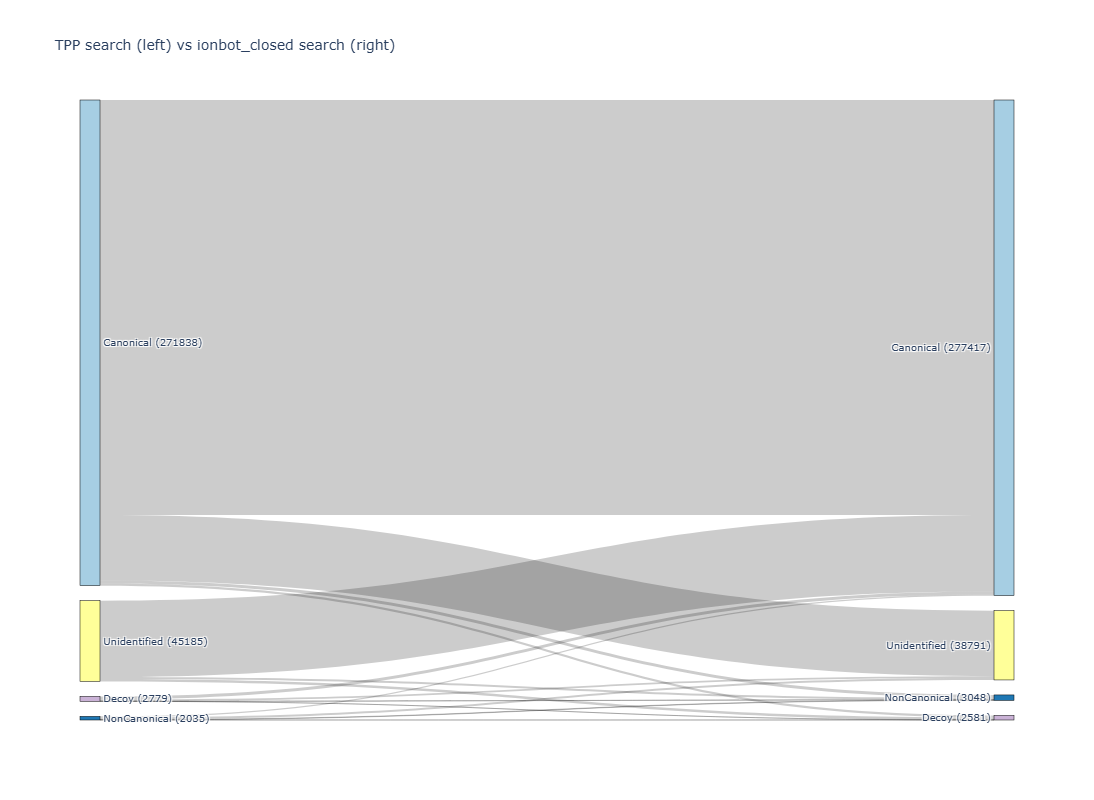

In [72]:
labels_w_num=[
    f"""{v.split(':')[1]} ({ 
        int(enr_sankey_data[enr_sankey_data.source_name == v.split(':')[1]].link_value.sum()) 
        if v.startswith(PIPELINE_CL) else
        int(enr_sankey_data[enr_sankey_data.target_name == v.split(':')[1]].link_value.sum()) if v.split(':')[1] in enr_sankey_data.target_name.tolist()
        else 0
    })"""
    for v in nodes_names_enr
]

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5), 
      label = labels_w_num, 
      color = list(labels_colors.values())
    ),
    link = dict(
      source = enr_sankey_data.link_source.tolist(),
      target = enr_sankey_data.link_target.tolist(),
      value = enr_sankey_data.link_value.tolist()
  ))])

fig.update_layout(title_text=f"{PIPELINE_CL} search (left) vs {PIPELINE_N} search (right)", font_size=10)
fig.update_layout(height=800, width=800,)
fig.write_image(f"{plot_dir}/pepcl_switch.svg")
fig.show()